# Feature Conditioning Regression — 0DTE Strategies (Massive Dataset)

**Justification du conditionnement** (Parts 9 & 14)

Modèle : $r_t = \\alpha + \\beta_1 \\text{VIX}_t + \\beta_2 \\text{VRP}_t + \\beta_3 \\text{IVSkew}_t + \\beta_4 \\text{RVSkew}_{t-1} + \\varepsilon_t$

**Datasets utilisés (`data/derived/SPX/`) :**

| Source | Contenu |
|---|---|
| `massive_strategy_5min.parquet` | PnL stratégies (`reth_und_net`) |
| `vix_5min.parquet` | VIX 0DTE SPXW |
| `slopes_5min.parquet` | `iv_atm`, `slope_dn` (IVSkew) |
| `realized_moments_5min.parquet` | `SPX_lrv`, `SPX_lrv_skew` (RVSkew$_{t-1}$) |

**Features (toutes ex-ante à 10:00) :**

| Feature | Définition | Timing |
|---|---|---|
| $\\text{VIX}_t$ | `iv_atm` à 10:00 (vol annualisée) | Snapshot avant le trade ✓ |
| $\\text{VRP}_t = \\text{vix}\\times10^5 - \\text{SPX\\_lrv}$ | IV variance − RV réalisée passée | IV à 10:00 ; RV = lag 1 |
| $\\text{IVSkew}_t$ | `slope_dn` à 10:00 | Pente put-wing avant le trade ✓ |
| $\\text{RVSkew}_{t-1}$ | `SPX_lrv_skew` | Skew RV du jour précédent ✓ |

OLS + combo FE + Newey-West SE (5 lags).

In [94]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from IPython.display import display

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO/'data').exists(): REPO = REPO.parent
DERIVED = REPO / 'data' / 'derived' / 'SPX'
MACRO   = REPO / 'data' / 'external' / 'macro' / 'macro_daily_controls.csv'

plt.rcParams.update({
    'figure.dpi':130,'axes.spines.top':False,'axes.spines.right':False,
    'font.size':11,'axes.titlesize':12,'axes.labelsize':10,
    'xtick.labelsize':9,'ytick.labelsize':9,'legend.fontsize':9,
    'axes.grid':True,'grid.alpha':0.35,'grid.linewidth':0.5,
})
PAL = ['#2166ac','#d6604d','#4dac26','#762a83']

# All 11 designed strategies (7 Vilkov + 4 extras)
STRAT_KEYS = [
    'strangle','iron_condor','risk_reversal',
    'bull_call_spread','call_ratio_spread','bear_put_spread','put_ratio_spread',
    'straddle','iron_butterfly','call_butterfly','put_butterfly',
]
STRAT_LBL = {
    'strangle':         'Strangle',
    'iron_condor':      'Iron Condor',
    'risk_reversal':    'Risk Reversal',
    'bull_call_spread': 'Bull C/Spread',
    'call_ratio_spread':'C/Ratio',
    'bear_put_spread':  'Bear P/Spread',
    'put_ratio_spread': 'P/Ratio',
    'straddle':         'Straddle',
    'iron_butterfly':   'Iron Butterfly',
    'call_butterfly':   'Call Butterfly',
    'put_butterfly':    'Put Butterfly',
}
# Representative moneyness per strategy (used for regime bars)
REP_MNES = {
    'strangle':          '0.995/1.005',
    'iron_condor':       '0.995/0.997/1.003/1.005',
    'risk_reversal':     '0.995/1.005',
    'bull_call_spread':  '1/1.005',
    'bear_put_spread':   '0.995/1',
    'call_ratio_spread': '1/1.005',
    'put_ratio_spread':  '0.995/1',
    'straddle':          '1/1',
    'iron_butterfly':    '0.995/1/1.005',
    'call_butterfly':    '0.99/1/1.01',
    'put_butterfly':     '0.98/0.99/1',
}
print(f'Repo  : {REPO}')
print(f'Data  : {DERIVED}')
print(f'Exists: {DERIVED.exists()}')

Repo  : /Users/dnn/Oxford/0DTE Options/0dte-strategies
Data  : /Users/dnn/Oxford/0DTE Options/0dte-strategies/data/derived/SPX
Exists: True


## 1. Chargement des données (massive dataset)

In [95]:
# ── PnL stratégies — toutes les entry times ──────────────────────────────────
# Utilise reth_und_net (net de costs = half-spread + fee)
# Toutes les 72 heures d'entrée (10:00–15:55) ; le signal de conditionnement
# (VIX, VRP…) est journalier → même valeur pour toutes les heures du jour.
pnl = pd.read_parquet(DERIVED / 'massive_strategy_5min.parquet')
pnl['quote_date'] = pd.to_datetime(pnl['quote_date'])
pnl['quote_time'] = pnl['quote_time'].astype(str)
pnl = pnl[pnl['option_type'].isin(STRAT_KEYS)].copy()
pnl['mnes'] = pnl['mnes'].astype(str)
pnl = pnl[['quote_date','quote_time','option_type','mnes','reth_und_net','reth_und']].dropna(subset=['reth_und_net'])

print(f'PnL : {len(pnl):,} obs  |  {pnl["quote_date"].nunique()} dates  |  {pnl["quote_time"].nunique()} entry times')
print(f'Période : {pnl["quote_date"].min().date()} -> {pnl["quote_date"].max().date()}')
pnl.groupby('option_type')['reth_und_net'].agg(['mean','std','count']).round(4)

PnL : 4,562,610 obs  |  992 dates  |  72 entry times
Période : 2022-04-01 -> 2026-05-08


,mean,std,count
option_type,,,
bear_put_spread,-0.0002,0.0037,713371
bull_call_spread,-0.0001,0.0037,712600
call_butterfly,-0.0001,0.0021,214068
call_ratio_spread,-0.0001,0.0039,712600
iron_butterfly,0.0001,0.0027,284828
iron_condor,-0.0000,0.0011,213954
put_butterfly,-0.0001,0.0022,213899
put_ratio_spread,-0.0001,0.0036,713371
risk_reversal,0.0000,0.0025,356268


In [96]:
# ── VIX level + VRP + RVSkew ─────────────────────────────────────────────────
# Timing note (build_data_massive.py, compute_realized_moments_5min) :
#   SPX_lrv at quote_time t = Σ (log-return)² from t+1 → 16:00  ← FORWARD-LOOKING
#   → SPX_lrv / SPX_lrv_skew are TARGET variables, NOT features.
#
# Fix : lag by 1 trading day so we use yesterday's ex-post realized variance :
#   vrp(t)      = IV_0DTE(t-1) − RV_forward(t-1)   [known at open of day t]
#   rv_skew(t)  = RV_skew(t-1)                      [known at open of day t]
# vix_level and iv_skew come from option prices at 10:00 on day t → concurrent, OK.

vix_raw = pd.read_parquet(DERIVED / 'vix_5min.parquet')
vix_raw['quote_date'] = pd.to_datetime(vix_raw['quote_date'])
vix_raw['quote_time'] = vix_raw['quote_time'].astype(str).str[:5]
vix10 = vix_raw[(vix_raw['dts']==0) & (vix_raw['quote_time']=='10:00')].copy()
if 'root' in vix10.columns: vix10 = vix10[vix10['root']=='SPXW']
vix10 = vix10.groupby('quote_date',as_index=False)['vix'].mean()

rm = pd.read_parquet(DERIVED / 'realized_moments_5min.parquet')
rm['quote_date'] = pd.to_datetime(rm['quote_date'])
rm['quote_time'] = rm['quote_time'].astype(str).str[:5]
rm10 = rm[rm['quote_time']=='10:00'][['quote_date','SPX_lrv','SPX_lrv_skew']].copy()

sl = pd.read_parquet(DERIVED / 'slopes_5min.parquet')
sl['quote_date'] = pd.to_datetime(sl['quote_date'])
sl['quote_time'] = sl['quote_time'].astype(str).str[:5]
sl10 = sl[sl['quote_time']=='10:00'][['quote_date','iv_atm','slope_dn']].dropna()

feat_df = (vix10.merge(rm10, on='quote_date', how='inner')
                .merge(sl10, on='quote_date', how='inner'))
feat_df = feat_df.sort_values('quote_date').reset_index(drop=True)

# Concurrent signals (known at 10:00 on day t)
feat_df['vix_level'] = feat_df['iv_atm']      # 0DTE ATM vol%, e.g. 0.27 = 27%
feat_df['iv_skew']   = feat_df['slope_dn']    # IV slope (put wing steepness)

# Lagged signals (shift by 1 day → yesterday's ex-post value, known at open)
feat_df['vrp']     = (feat_df['vix'] * 1e5 - feat_df['SPX_lrv']).shift(1)
feat_df['rv_skew'] = feat_df['SPX_lrv_skew'].shift(1)

feat_df = feat_df[['quote_date','vix_level','iv_skew','vrp','rv_skew']].dropna()

print(f'Features : {len(feat_df):,} lignes  (1 date lost to lag)')
display(feat_df.describe().round(4))


Features : 993 lignes  (1 date lost to lag)


,quote_date,vix_level,iv_skew,vrp,rv_skew
count,993,993.0000,993.0000,993.0000,993.0000
mean,2024-04-14 12:35:31.722054,0.2710,4.5737,0.2412,0.0212
min,2022-04-04 00:00:00,0.0959,-4.0230,-309.9127,-22.4793
25%,2023-04-13 00:00:00,0.1787,2.8946,-0.0684,-0.7142
50%,2024-04-11 00:00:00,0.2347,4.4162,0.8244,-0.0248
75%,2025-04-11 00:00:00,0.3257,6.2264,1.8808,0.4022
max,2026-05-12 00:00:00,1.2781,18.0434,22.6417,119.3303
std,NaN,0.1330,2.5200,11.3105,5.0205


In [97]:
# ── Event dummies ─────────────────────────────────────────────────────────────
macro = pd.read_csv(MACRO)
macro['quote_date'] = pd.to_datetime(macro['quote_date'])
col_map = {}
for c in macro.columns:
    lc=c.lower()
    if 'fomc' in lc: col_map[c]='is_fomc'
    elif 'cpi' in lc: col_map[c]='is_cpi'
    elif 'nfp' in lc: col_map[c]='is_nfp'
macro = macro.rename(columns=col_map)
for c in ['is_fomc','is_cpi','is_nfp']:
    macro[c] = macro.get(c,pd.Series(0,index=macro.index)).fillna(0).astype(float)
evt_df = macro[['quote_date','is_fomc','is_cpi','is_nfp']].drop_duplicates('quote_date')
print(evt_df[['is_fomc','is_cpi','is_nfp']].sum().astype(int))

is_fomc    35
is_cpi     52
is_nfp     52
dtype: int64


In [98]:
# ── Merge + z-score ───────────────────────────────────────────────────────────
df = (pnl.merge(feat_df, on='quote_date', how='left')
         .merge(evt_df,  on='quote_date', how='left'))
df[['is_fomc','is_cpi','is_nfp']] = df[['is_fomc','is_cpi','is_nfp']].fillna(0)

CONT = ['vix_level','vrp','iv_skew','rv_skew']
for col in CONT:
    mu,sigma = df[col].mean(), df[col].std()
    df[f'{col}_z'] = (df[col]-mu)/sigma

q33,q67 = df['vix_level'].quantile([1/3,2/3])
df['vix_regime'] = pd.cut(df['vix_level'],bins=[-np.inf,q33,q67,np.inf],
                           labels=['Low VIX','Mid VIX','High VIX'])
df['event_type'] = 'No event'
df.loc[df['is_fomc']==1,'event_type']='FOMC'
df.loc[df['is_cpi'] ==1,'event_type']='CPI'
df.loc[df['is_nfp'] ==1,'event_type']='NFP'

print(f'Dataset : {len(df):,} x {df.shape[1]}')
print(f'Periode : {df["quote_date"].min().date()} -> {df["quote_date"].max().date()}')
print('NaN:',df[CONT].isna().sum().to_dict())

Dataset : 4,562,610 x 19
Periode : 2022-04-01 -> 2026-05-08
NaN: {'vix_level': 4608, 'vrp': 4608, 'iv_skew': 4608, 'rv_skew': 4608}


## 2. Exploration des features

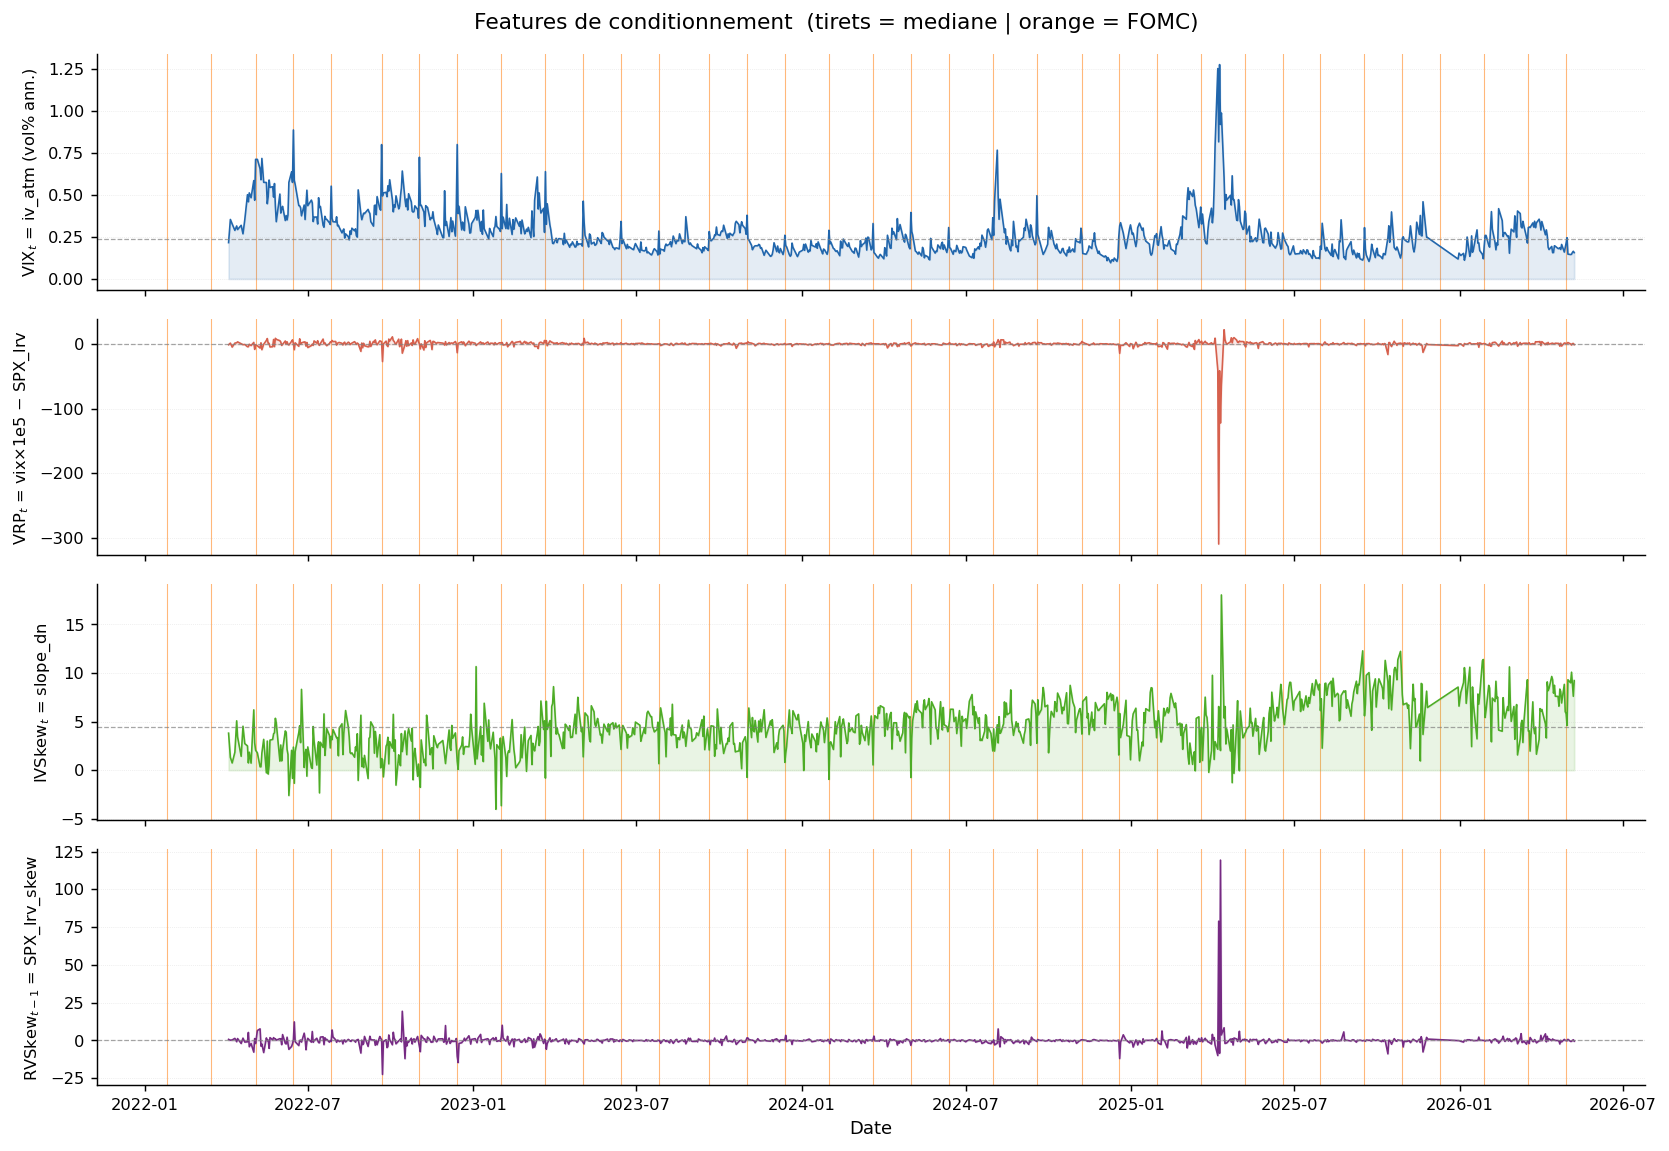

In [99]:
feat_daily = df.groupby('quote_date')[CONT].mean().dropna()
FEAT_META=[('vix_level',r'$\mathrm{VIX}_t$ = iv_atm (vol% ann.)',PAL[0]),
           ('vrp',      r'$\mathrm{VRP}_t$ = vix×1e5 − SPX_lrv', PAL[1]),
           ('iv_skew',  r'$\mathrm{IVSkew}_t$ = slope_dn',        PAL[2]),
           ('rv_skew',  r'$\mathrm{RVSkew}_{t-1}$ = SPX_lrv_skew',PAL[3])]
fomc_dates = evt_df[evt_df['is_fomc']==1]['quote_date']

fig,axes=plt.subplots(4,1,figsize=(13,9),sharex=True)
for ax,(col,label,color) in zip(axes,FEAT_META):
    y=feat_daily[col]
    ax.fill_between(y.index,y,alpha=0.12,color=color)
    ax.plot(y.index,y,lw=0.9,color=color)
    ax.axhline(y.median(),ls='--',lw=0.7,color='grey',alpha=0.7)
    for d in fomc_dates: ax.axvline(d,color='#ff7f0e',lw=0.6,alpha=0.55,zorder=0)
    ax.set_ylabel(label,fontsize=9)
    ax.grid(axis='y',lw=0.4,ls=':'); ax.grid(axis='x',visible=False)
axes[-1].set_xlabel('Date')
fig.suptitle('Features de conditionnement  (tirets = mediane | orange = FOMC)',fontsize=12)
plt.tight_layout(); plt.show()

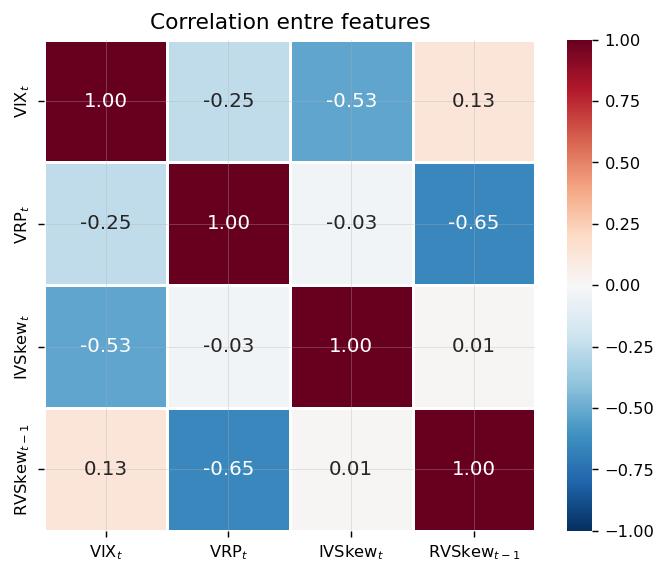

In [100]:
nice={'vix_level':r'VIX$_t$','vrp':r'VRP$_t$','iv_skew':r'IVSkew$_t$','rv_skew':r'RVSkew$_{t-1}$'}
corr=df[CONT].rename(columns=nice).corr()
fig,ax=plt.subplots(figsize=(5.5,4.5))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdBu_r',center=0,vmin=-1,vmax=1,
            ax=ax,square=True,linewidths=0.6,annot_kws={'size':11})
ax.set_title('Correlation entre features')
plt.tight_layout(); plt.show()

In [101]:
df

,quote_date,quote_time,option_type,mnes,reth_und_net,reth_und,vix_level,iv_skew,vrp,rv_skew,is_fomc,is_cpi,is_nfp,vix_level_z,vrp_z,iv_skew_z,rv_skew_z,vix_regime,event_type
0,2022-04-01,10:00,bear_put_spread,0.975/1,-0.003102,-0.002996,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NFP
1,2022-04-01,10:00,bear_put_spread,0.975/1.025,-0.002917,-0.001632,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NFP
2,2022-04-01,10:00,bear_put_spread,0.98/1,-0.003091,-0.002985,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NFP
3,2022-04-01,10:00,bear_put_spread,0.98/1.02,-0.001892,-0.001390,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NFP
4,2022-04-01,10:00,bear_put_spread,0.985/1,-0.003047,-0.002941,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NFP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4562605,2026-05-08,15:55,strangle,0.975/1.025,-0.000004,0.000000,0.156343,9.225985,-0.498889,-0.509953,0.0,0.0,1.0,-0.864485,-0.06511,1.85255,-0.105562,Low VIX,NFP
4562606,2026-05-08,15:55,strangle,0.98/1.02,-0.000004,0.000000,0.156343,9.225985,-0.498889,-0.509953,0.0,0.0,1.0,-0.864485,-0.06511,1.85255,-0.105562,Low VIX,NFP
4562607,2026-05-08,15:55,strangle,0.985/1.015,-0.000004,0.000000,0.156343,9.225985,-0.498889,-0.509953,0.0,0.0,1.0,-0.864485,-0.06511,1.85255,-0.105562,Low VIX,NFP
4562608,2026-05-08,15:55,strangle,0.99/1.01,-0.000004,0.000000,0.156343,9.225985,-0.498889,-0.509953,0.0,0.0,1.0,-0.864485,-0.06511,1.85255,-0.105562,Low VIX,NFP


## 3. PnL par regime VIX

/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_21289/4029102748.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(); plt.show()


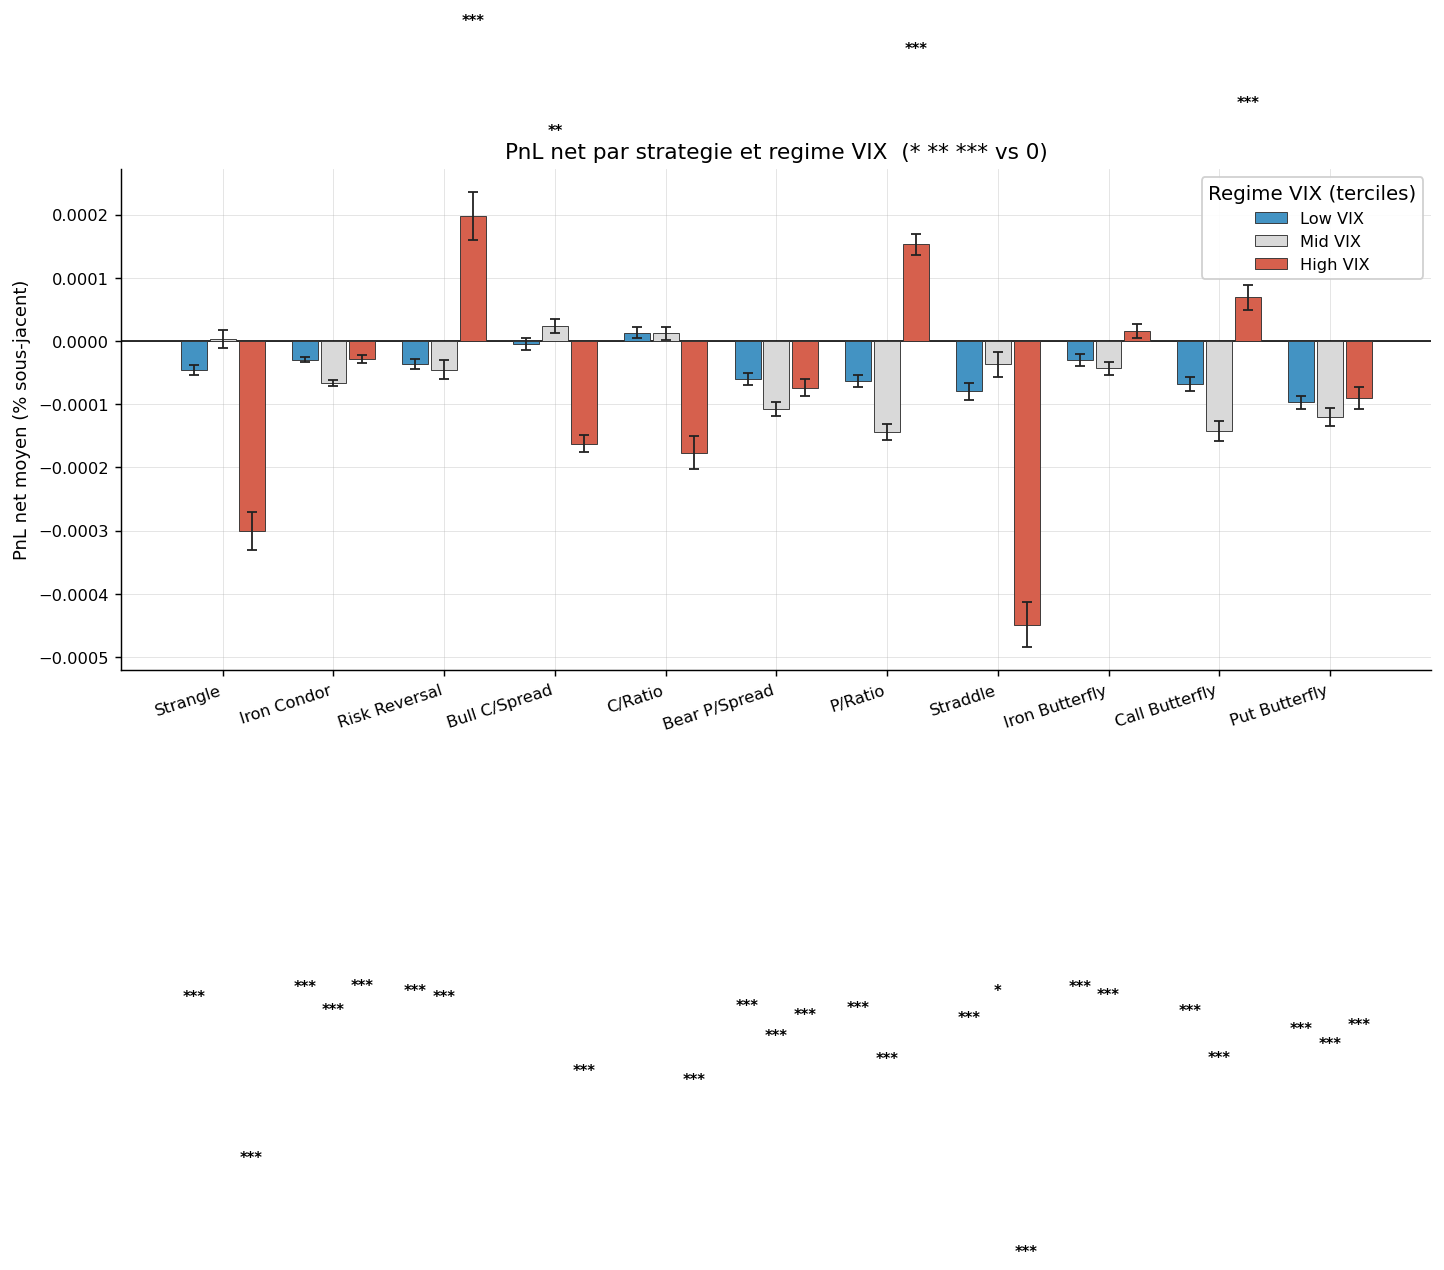

In [102]:
def sig_stars(p): return '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
REGIMES=['Low VIX','Mid VIX','High VIX']
RC={'Low VIX':'#4393c3','Mid VIX':'#d9d9d9','High VIX':'#d6604d'}

# Filter to rep mnes for clarity; pool all entry times (daily signal → same regime for all hours)
df_rep = df[df['mnes'] == df['option_type'].map(REP_MNES)]
reg_stats=(df_rep.groupby(['option_type','vix_regime'],observed=True)['reth_und_net']
           .agg(['mean','std','count']).reset_index())
reg_stats['se']=reg_stats['std']/np.sqrt(reg_stats['count'])
pval_reg=(df_rep.groupby(['option_type','vix_regime'],observed=True)['reth_und_net']
          .apply(lambda g: stats.ttest_1samp(g.dropna(),0).pvalue).reset_index(name='pval'))
reg_stats=reg_stats.merge(pval_reg,on=['option_type','vix_regime'])

fig,ax=plt.subplots(figsize=(13,5))
x,w=np.arange(len(STRAT_KEYS)),0.26
for i,regime in enumerate(REGIMES):
    sub=(reg_stats[reg_stats['vix_regime']==regime].set_index('option_type').reindex(STRAT_KEYS))
    bars=ax.bar(x+(i-1)*w,sub['mean'],width=w*0.9,label=regime,
                color=RC[regime],edgecolor='#333',lw=0.5,zorder=3)
    ax.errorbar(x+(i-1)*w,sub['mean'],yerr=sub['se'],
                fmt='none',color='#222',capsize=3,lw=1.0,zorder=4)
    for bar,row in zip(bars,sub.itertuples()):
        st=sig_stars(row.pval)
        if st and not np.isnan(bar.get_height()):
            h=bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2,h+0.0003 if h>=0 else h-0.001,
                    st,ha='center',va='bottom',fontsize=8,fontweight='bold')

ax.axhline(0,color='black',lw=0.9)
ax.set_xticks(x); ax.set_xticklabels([STRAT_LBL[s] for s in STRAT_KEYS],rotation=18,ha='right')
ax.set_ylabel('PnL net moyen (% sous-jacent)')
ax.set_title('PnL net par strategie et regime VIX  (* ** *** vs 0)')
ax.legend(title='Regime VIX (terciles)',loc='upper right',framealpha=0.9)
plt.tight_layout(); plt.show()

## 4. Panel A — Regression OLS

In [103]:
def run_ols_nw(sub_df, y_col, x_cols,
               fe_cols=('mnes','quote_time'), cluster_col='quote_date', nw_lags=5):
    """OLS with two-way within demeaning (mnes × entry_time) and date-clustered SE.
    
    fe_cols   : tuple of columns to sequentially demean (absorbs FE without dummies).
    cluster_col: cluster SE by date to handle within-day correlation from shared
                 daily conditioning signal (VIX, VRP…).
    """
    keep = [y_col] + x_cols + list(fe_cols) + ([cluster_col] if cluster_col else [])
    sub  = sub_df[[c for c in keep if c in sub_df.columns]].dropna().copy()
    if len(sub) < 30: return None
    # Sequential demeaning over each FE (Frisch-Waugh within estimator)
    for fe in fe_cols:
        if fe in sub.columns:
            for col in [y_col] + x_cols:
                sub[col] -= sub.groupby(fe)[col].transform('mean')
    y = sub[y_col].values
    X = sm.add_constant(sub[x_cols].values)
    if cluster_col and cluster_col in sub.columns:
        groups = sub[cluster_col].values
        return sm.OLS(y, X).fit(cov_type='cluster',
                                cov_kwds={'groups': groups, 'use_correction': True})
    return sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags, 'use_correction': True})

def stars(p): return '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''

FEAT_A=[
    ('vix_level_z', r'VIX$_t$'),
    ('vrp_z',       r'VRP$_{t-1}$'),
    ('iv_skew_z',   r'IVSkew$_t$'),
    ('rv_skew_z',   r'RVSkew$_{t-1}$'),
]
x_cols_a=[c for c,_ in FEAT_A]
# Utilise reth_und_net (net des couts)
res_a={s:run_ols_nw(df[df['option_type']==s],'reth_und_net',x_cols_a) for s in STRAT_KEYS}

rows=[]
for i,(col,label) in enumerate(FEAT_A):
    rc={'Feature':label}; rt={'Feature':''}
    for s in STRAT_KEYS:
        r=res_a[s]
        if r is None: rc[STRAT_LBL[s]]=rt[STRAT_LBL[s]]=''
        else:
            c,p,t=r.params[i+1],r.pvalues[i+1],r.tvalues[i+1]
            rc[STRAT_LBL[s]]=f'{c:.4f}{stars(p)}'; rt[STRAT_LBL[s]]=f'({t:.2f})'
    rows+=[rc,rt]
for lbl,attr in [('R2 Adj.','rsquared_adj'),('Obs.','nobs')]:
    row={'Feature':lbl}
    for s in STRAT_KEYS:
        r=res_a[s]
        row[STRAT_LBL[s]]=(f"{int(r.nobs):,}" if attr=='nobs' else f"{getattr(r,attr):.3f}") if r else ''
    rows.append(row)
print('Panel A — massive dataset, reth_und_net, combo FE, NW SE')
display(pd.DataFrame(rows).set_index('Feature'))

Panel A — massive dataset, reth_und_net, combo FE, NW SE


,Strangle,Iron Condor,Risk Reversal,Bull C/Spread,C/Ratio,Bear P/Spread,P/Ratio,Straddle,Iron Butterfly,Call Butterfly,Put Butterfly
Feature,,,,,,,,,,,
VIX$_t$,0.0001,0.0000,0.0006,0.0001,-0.0002,-0.0002,0.0000,-0.0000,0.0001,0.0000,-0.0000
,(0.24),(0.74),(1.42),(0.71),(-0.71),(-1.28),(0.10),(-0.12),(1.00),(0.22),(-0.72)
VRP$_{t-1}$,-0.0005**,0.0001**,0.0002,0.0002,0.0004**,-0.0003*,0.0001,-0.0007***,0.0001*,0.0001**,-0.0000
,(-2.54),(2.28),(0.51),(1.45),(2.18),(-1.77),(0.73),(-2.58),(1.73),(2.51),(-0.22)
IVSkew$_t$,0.0000,0.0000,0.0003*,0.0003**,0.0001,-0.0003**,-0.0002*,-0.0000,0.0001,0.0001**,-0.0001*
,(0.25),(1.09),(1.67),(2.26),(0.47),(-2.52),(-1.75),(-0.04),(0.79),(2.32),(-1.82)
RVSkew$_{t-1}$,-0.0004,0.0000,-0.0002,0.0000,0.0003,-0.0000,0.0000,-0.0004,0.0001,0.0000,0.0000
,(-1.45),(0.89),(-0.74),(0.06),(1.51),(-0.20),(0.39),(-1.29),(0.51),(1.03),(0.24)
R2 Adj.,0.036,0.003,0.045,0.006,0.013,0.008,0.002,0.017,0.002,0.002,0.001


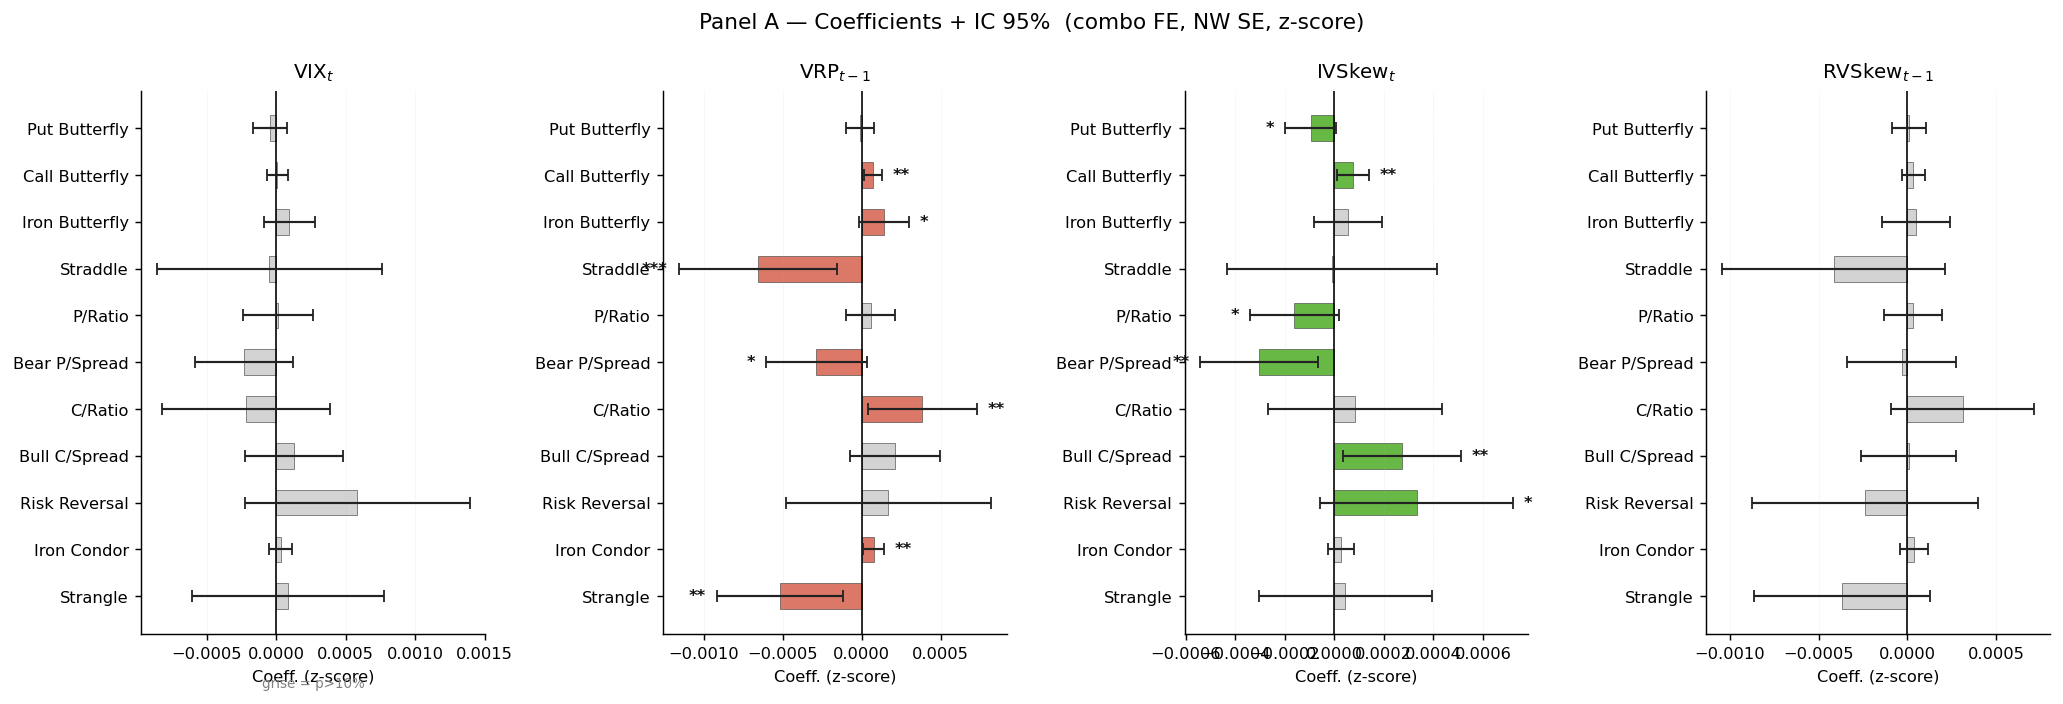

In [104]:
# Coefficient plots avec etoiles
FLBL_C={label: PAL[i % len(PAL)] for i, (_, label) in enumerate(FEAT_A)}
fig,axes=plt.subplots(1,4,figsize=(16,5.5))
for ax,(col,label) in zip(axes,FEAT_A):
    idx=x_cols_a.index(col)+1
    coefs,cilo,cihi,slabels,pvals=[],[],[],[],[]
    for s in STRAT_KEYS:
        r=res_a[s]
        if r is None: continue
        c,se,p=r.params[idx],r.bse[idx],r.pvalues[idx]
        coefs.append(c); cilo.append(c-1.96*se); cihi.append(c+1.96*se)
        slabels.append(STRAT_LBL[s]); pvals.append(p)
    y_pos=np.arange(len(coefs))
    bc=[FLBL_C[label] if p<0.10 else '#cccccc' for p in pvals]
    ax.barh(y_pos,coefs,color=bc,alpha=0.85,height=0.55,edgecolor='#444',lw=0.4)
    ax.errorbar(coefs,y_pos,
                xerr=[np.array(coefs)-np.array(cilo),np.array(cihi)-np.array(coefs)],
                fmt='none',color='#222',capsize=3.5,lw=1.2,zorder=5)
    xmax=max(abs(min(cilo,default=0.1)),abs(max(cihi,default=0.1)))
    for yi,(c,p) in enumerate(zip(coefs,pvals)):
        st=stars(p)
        if st:
            xp=cihi[yi]+xmax*0.06 if c>=0 else cilo[yi]-xmax*0.06
            ax.text(xp,yi,st,va='center',ha='left' if c>=0 else 'right',
                    fontsize=9,fontweight='bold',color='#111')
    ax.axvline(0,color='black',lw=0.9)
    ax.set_yticks(y_pos); ax.set_yticklabels(slabels,fontsize=9)
    ax.set_title(label,fontsize=11,pad=7)
    ax.set_xlabel('Coeff. (z-score)',fontsize=9)
    ax.grid(axis='x',lw=0.4,ls=':'); ax.grid(axis='y',visible=False)
    if label==r'VIX$_t$':
        ax.text(0.5,-0.10,'grise = p>10%',transform=ax.transAxes,
                ha='center',fontsize=7.5,color='grey')
fig.suptitle('Panel A — Coefficients + IC 95%  (combo FE, NW SE, z-score)',fontsize=12)
plt.tight_layout(); plt.show()

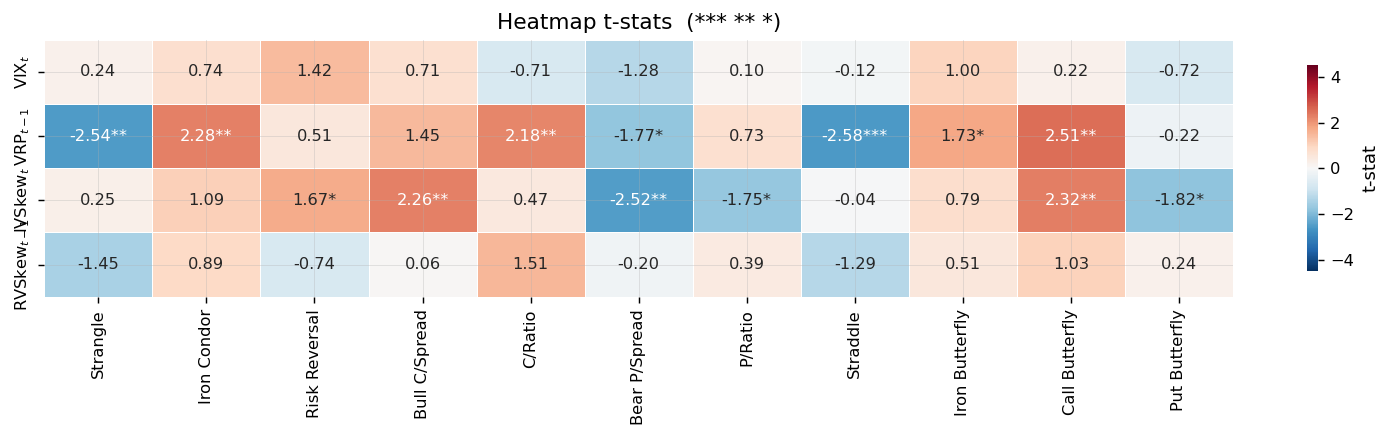

In [105]:
# Heatmap t-stats
tmat=pd.DataFrame({STRAT_LBL[s]:[res_a[s].tvalues[i+1] if res_a[s] else np.nan
                                   for i in range(len(FEAT_A))] for s in STRAT_KEYS},
                   index=[l for _,l in FEAT_A])
annot=pd.DataFrame({STRAT_LBL[s]:[f"{res_a[s].tvalues[i+1]:.2f}{stars(res_a[s].pvalues[i+1])}"
                                    if res_a[s] else '' for i in range(len(FEAT_A))] for s in STRAT_KEYS},
                    index=[l for _,l in FEAT_A])
fig,ax=plt.subplots(figsize=(12,3.5))
sns.heatmap(tmat,annot=annot,fmt='',cmap='RdBu_r',center=0,vmin=-4.5,vmax=4.5,
            ax=ax,linewidths=0.5,cbar_kws={'label':'t-stat','shrink':0.8},annot_kws={'size':9})
ax.set_title('Heatmap t-stats  (*** ** *)')
plt.tight_layout(); plt.show()

## 5. Panel B — ANOVA Event Days

/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_21289/1437546406.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EVENT_ORDER,rotation=25,ha='right',fontsize=8)
/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_21289/1437546406.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EVENT_ORDER,rotation=25,ha='right',fontsize=8)
/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_21289/1437546406.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EVENT_ORDER,rotation=25,ha='right',fontsize=8)
/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_21289/1437546406.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

IndexError: index 8 is out of bounds for axis 0 with size 8

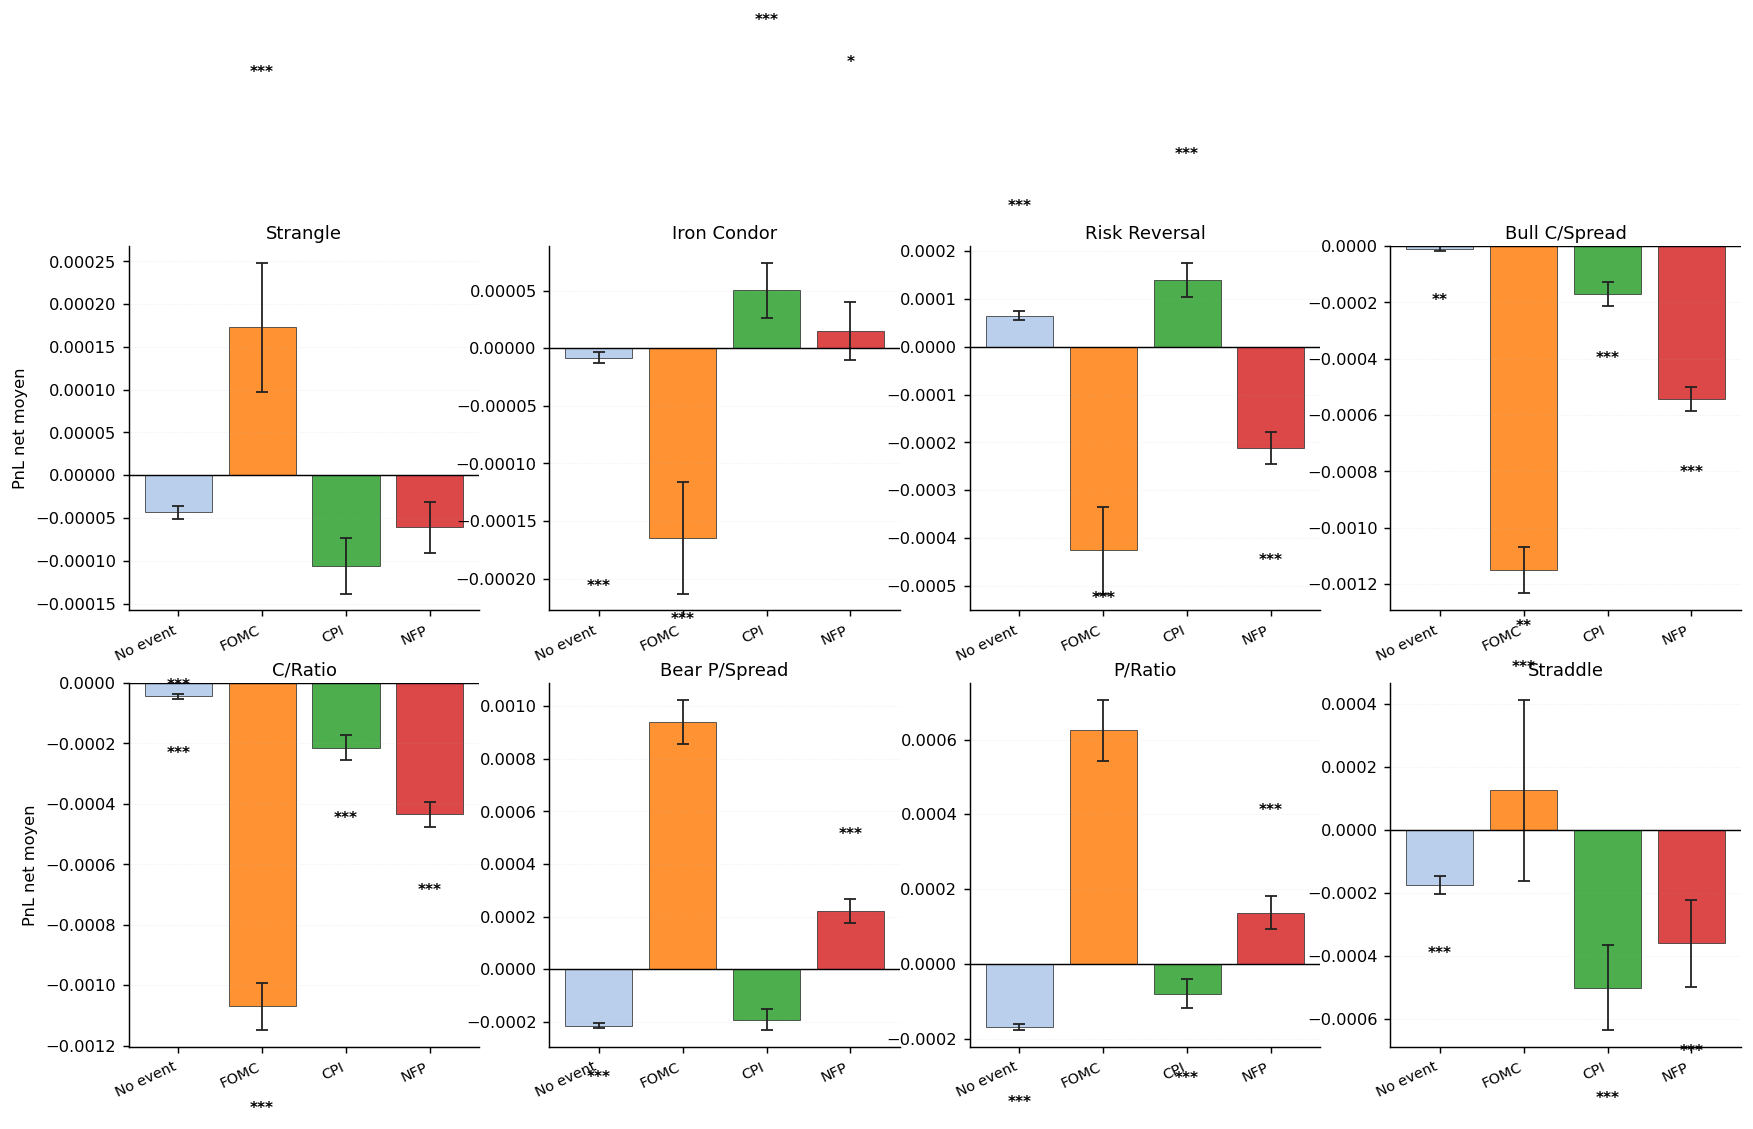

In [106]:
EVENT_ORDER=['No event','FOMC','CPI','NFP']
EC={'No event':'#aec7e8','FOMC':'#ff7f0e','CPI':'#2ca02c','NFP':'#d62728'}

fig,axes=plt.subplots(2,4,figsize=(16,8))
for i,strat in enumerate(STRAT_KEYS):
    ax=axes.flat[i]
    sub=df[df['option_type']==strat]
    base=sub[sub['event_type']=='No event']['reth_und_net'].dropna()
    means,ses,pvals=[],[],[]
    for evt in EVENT_ORDER:
        grp=sub[sub['event_type']==evt]['reth_und_net'].dropna()
        if len(grp)<3: means.append(np.nan);ses.append(np.nan);pvals.append(np.nan)
        else:
            means.append(grp.mean()); ses.append(grp.std()/np.sqrt(len(grp)))
            pvals.append(stats.ttest_1samp(grp,0).pvalue if evt=='No event'
                         else stats.ttest_ind(grp,base,equal_var=False).pvalue)
    bars=ax.bar(EVENT_ORDER,means,color=[EC[e] for e in EVENT_ORDER],edgecolor='#333',lw=0.5,alpha=0.85)
    ax.errorbar(EVENT_ORDER,means,
                yerr=[1.96*(se if se and not np.isnan(se) else 0) for se in ses],
                fmt='none',color='#222',capsize=3.5,lw=1.0)
    for bar,m,se,p in zip(bars,means,ses,pvals):
        if m is None or np.isnan(m) or p is None or np.isnan(p): continue
        st=sig_stars(p)
        if st:
            yoff=(1.96*(se if se else 0))+abs(m)*0.08+0.0002
            ax.text(bar.get_x()+bar.get_width()/2,m+yoff if m>=0 else m-yoff,
                    st,ha='center',va='bottom',fontsize=8.5,fontweight='bold')
    ax.axhline(0,color='black',lw=0.8)
    ax.set_title(STRAT_LBL[strat],fontsize=10,pad=4)
    ax.set_xticklabels(EVENT_ORDER,rotation=25,ha='right',fontsize=8)
    ax.set_ylabel('PnL net moyen' if i%4==0 else '',fontsize=9)
    ax.grid(axis='y',lw=0.3,ls=':'); ax.grid(axis='x',visible=False)
axes.flat[-1].set_visible(False)
fig.suptitle('PnL net par type de jour  (* vs 0 pour No event ; * vs No event pour les autres)',fontsize=11)
plt.tight_layout(); plt.show()

In [107]:
# Regression dummies + F-test
EVENT_COLS=[('is_fomc','FOMC'),('is_cpi','CPI'),('is_nfp','NFP')]
x_cols_b=[c for c,_ in EVENT_COLS]
res_b,fpvals={},{}
for s in STRAT_KEYS:
    r=run_ols_nw(df[df['option_type']==s],'reth_und_net',x_cols_b)
    res_b[s]=r
    if r is None: fpvals[s]=np.nan; continue
    R=np.zeros((len(x_cols_b),len(r.params)))
    for k in range(len(x_cols_b)): R[k,k+1]=1.0
    try: fpvals[s]=float(r.wald_test(R,use_f=True,scalar=True).pvalue)
    except:
        try: fpvals[s]=float(r.wald_test(R,use_f=True).pvalue)
        except: fpvals[s]=np.nan

rows_b=[]
for i,(col,label) in enumerate(EVENT_COLS):
    rc={'Feature':label}; rt={'Feature':''}
    for s in STRAT_KEYS:
        r=res_b[s]
        if r is None: rc[STRAT_LBL[s]]=rt[STRAT_LBL[s]]=''
        else:
            c,p,t=r.params[i+1],r.pvalues[i+1],r.tvalues[i+1]
            rc[STRAT_LBL[s]]=f'{c:.4f}{stars(p)}'; rt[STRAT_LBL[s]]=f'({t:.2f})'
    rows_b+=[rc,rt]
frow={'Feature':'F-test p'}
for s in STRAT_KEYS:
    p=fpvals.get(s,np.nan)
    frow[STRAT_LBL[s]]=f'{p:.3f}{stars(p)}' if not np.isnan(p) else ''
rows_b.append(frow)
for lbl,attr in [('R2 Adj.','rsquared_adj'),('Obs.','nobs')]:
    row={'Feature':lbl}
    for s in STRAT_KEYS:
        r=res_b[s]
        row[STRAT_LBL[s]]=(f"{int(r.nobs):,}" if attr=='nobs' else f"{getattr(r,attr):.3f}") if r else ''
    rows_b.append(row)
print('Panel B')
display(pd.DataFrame(rows_b).set_index('Feature'))

Panel B


,Strangle,Iron Condor,Risk Reversal,Bull C/Spread,C/Ratio,Bear P/Spread,P/Ratio,Straddle,Iron Butterfly,Call Butterfly,Put Butterfly
Feature,,,,,,,,,,,
FOMC,0.0002,-0.0001,-0.0005,-0.0012,-0.0011,0.0012,0.0008,0.0002,-0.0000,-0.0003,0.0002
,(0.36),(-0.50),(-0.73),(-1.38),(-1.58),(1.23),(1.17),(0.19),(-0.07),(-1.42),(0.60)
CPI,-0.0001,0.0001,0.0001,-0.0001,-0.0001,-0.0000,0.0001,-0.0003,0.0003,-0.0000,-0.0000
,(-0.39),(0.59),(0.47),(-0.33),(-0.43),(-0.01),(0.21),(-0.81),(0.95),(-0.36),(-0.15)
NFP,-0.0000,0.0000,-0.0003,-0.0005,-0.0004,0.0004,0.0003,-0.0002,0.0002,-0.0001,0.0001
,(-0.14),(0.25),(-1.63),(-1.30),(-1.03),(0.94),(0.83),(-0.51),(0.62),(-0.53),(0.25)
F-test p,0.965,0.886,0.322,0.303,0.303,0.502,0.560,0.824,0.746,0.493,0.932
R2 Adj.,0.000,0.001,0.002,0.004,0.003,0.003,0.002,0.000,0.001,0.001,0.000
Obs.,"356,268","213,954","356,268","712,600","712,600","713,371","713,371","71,383","284,828","214,068","213,899"


/var/folders/cg/ltgc1bw91_q800mfcy5vfvkw0000gn/T/ipykernel_21289/3971824826.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([STRAT_LBL[s] for s in STRAT_KEYS],rotation=18,ha='right')


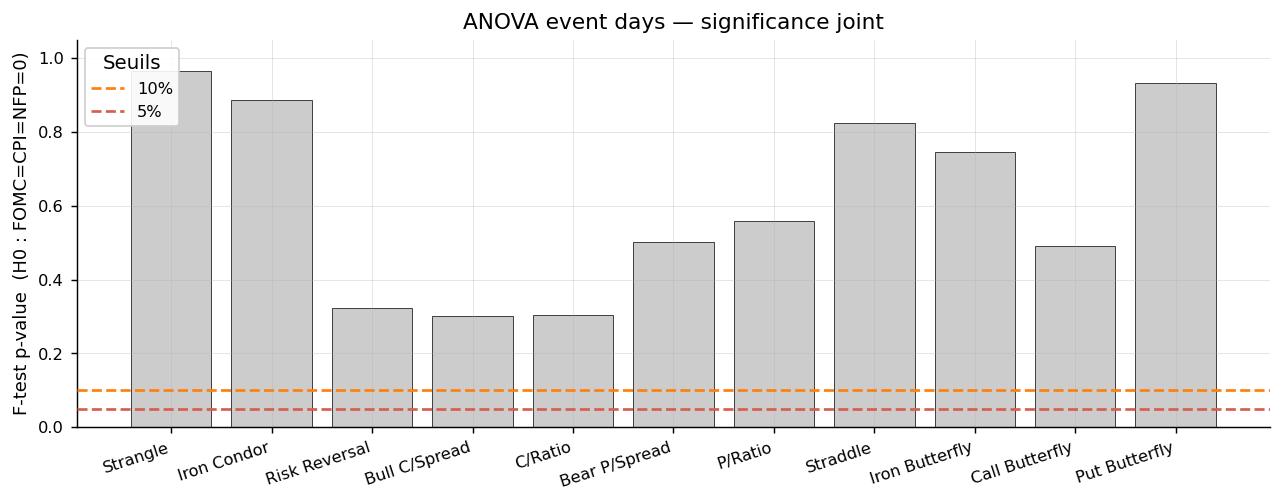

In [108]:
fp_vals=[fpvals.get(s,np.nan) for s in STRAT_KEYS]
fig,ax=plt.subplots(figsize=(10,4))
bars=ax.bar([STRAT_LBL[s] for s in STRAT_KEYS],fp_vals,
            color=[PAL[1] if p<0.10 else '#cccccc' for p in fp_vals],edgecolor='#333',lw=0.5)
for bar,p in zip(bars,fp_vals):
    st=stars(p)
    if st: ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,st,
                   ha='center',va='bottom',fontsize=9,fontweight='bold',color=PAL[1])
ax.axhline(0.10,ls='--',color='#ff7f0e',lw=1.5,label='10%',zorder=5)
ax.axhline(0.05,ls='--',color=PAL[1],lw=1.5,label='5%',zorder=5)
ax.set_ylim(0,1.05)
ax.set_ylabel('F-test p-value  (H0 : FOMC=CPI=NFP=0)')
ax.set_title('ANOVA event days — significance joint')
ax.set_xticklabels([STRAT_LBL[s] for s in STRAT_KEYS],rotation=18,ha='right')
ax.legend(title='Seuils',framealpha=0.9,loc='upper left')
plt.tight_layout(); plt.show()

## 6. Modele complet

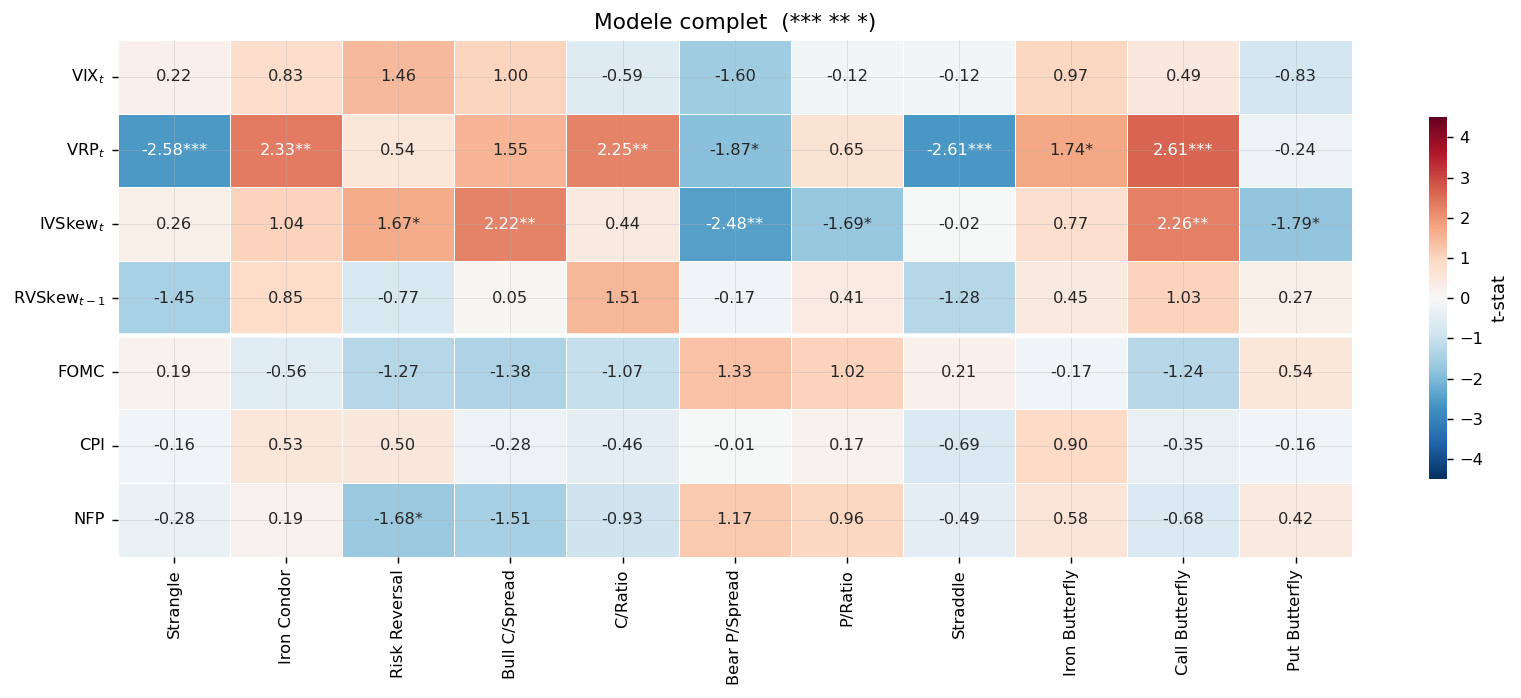

,R2 Panel A,R2 Full,N
Strategie,,,
Strangle,0.036,0.036,"355,908"
Iron Condor,0.003,0.003,"213,738"
Risk Reversal,0.045,0.051,"355,908"
Bull C/Spread,0.006,0.010,"711,880"
C/Ratio,0.013,0.014,"711,880"
Bear P/Spread,0.008,0.012,"712,651"
P/Ratio,0.002,0.004,"712,651"
Straddle,0.017,0.017,"71,311"
Iron Butterfly,0.002,0.002,"284,540"


In [109]:
ALL_FEAT=[('vix_level_z',r'VIX$_t$'),('vrp_z',r'VRP$_t$'),
           ('iv_skew_z',r'IVSkew$_t$'),('rv_skew_z',r'RVSkew$_{t-1}$'),
           ('is_fomc','FOMC'),('is_cpi','CPI'),('is_nfp','NFP')]
x_full=[c for c,_ in ALL_FEAT]
res_full={s:run_ols_nw(df[df['option_type']==s],'reth_und_net',x_full) for s in STRAT_KEYS}

tmat_f=pd.DataFrame({STRAT_LBL[s]:[res_full[s].tvalues[i+1] if res_full[s] else np.nan
                                     for i in range(len(ALL_FEAT))] for s in STRAT_KEYS},
                     index=[l for _,l in ALL_FEAT])
annot_f=pd.DataFrame({STRAT_LBL[s]:[f"{res_full[s].tvalues[i+1]:.2f}{stars(res_full[s].pvalues[i+1])}"
                                      if res_full[s] else '' for i in range(len(ALL_FEAT))] for s in STRAT_KEYS},
                      index=[l for _,l in ALL_FEAT])
fig,ax=plt.subplots(figsize=(13,5.5))
sns.heatmap(tmat_f,annot=annot_f,fmt='',cmap='RdBu_r',center=0,vmin=-4.5,vmax=4.5,
            ax=ax,linewidths=0.5,cbar_kws={'label':'t-stat','shrink':0.7},annot_kws={'size':9})
ax.axhline(4,color='white',lw=2.5)
ax.set_title('Modele complet  (*** ** *)',fontsize=12)
plt.tight_layout(); plt.show()

display(pd.DataFrame({
    'Strategie':[STRAT_LBL[s] for s in STRAT_KEYS],
    'R2 Panel A':[f"{res_a[s].rsquared_adj:.3f}" if res_a[s] else '' for s in STRAT_KEYS],
    'R2 Full':  [f"{res_full[s].rsquared_adj:.3f}" if res_full[s] else '' for s in STRAT_KEYS],
    'N':        [f"{int(res_full[s].nobs):,}" if res_full[s] else '' for s in STRAT_KEYS],
}).set_index('Strategie'))

---
## Multi-Signal Regime Grid

Mean net PnL (bps) par stratégie, conditionné sur les terciles de 6 signaux :
- **0DTE VIX** = intégrale de variance SPXW `dts=0` depuis `vix_5min` → `sqrt(vix × 252) × 100` (vol ann. %)
- **VRP** = `vix_0dte×1e5 − SPX_lrv` (prime de variance intraday)
- **IV Skew** = `slope_dn` (pente bas de la surface 0DTE)
- **RV Skew** = `SPX_lrv_skew` (skew de variance réalisée, lagged)
- **Macro VIX** = VIX CBOE 30j (`macro_daily_controls`)
- **SOFR** = taux sans risque (`macro_daily_controls`)

Barres = moyenne net PnL | error bars = ±1 SE | \* \*\* \*\*\* = t-test vs 0

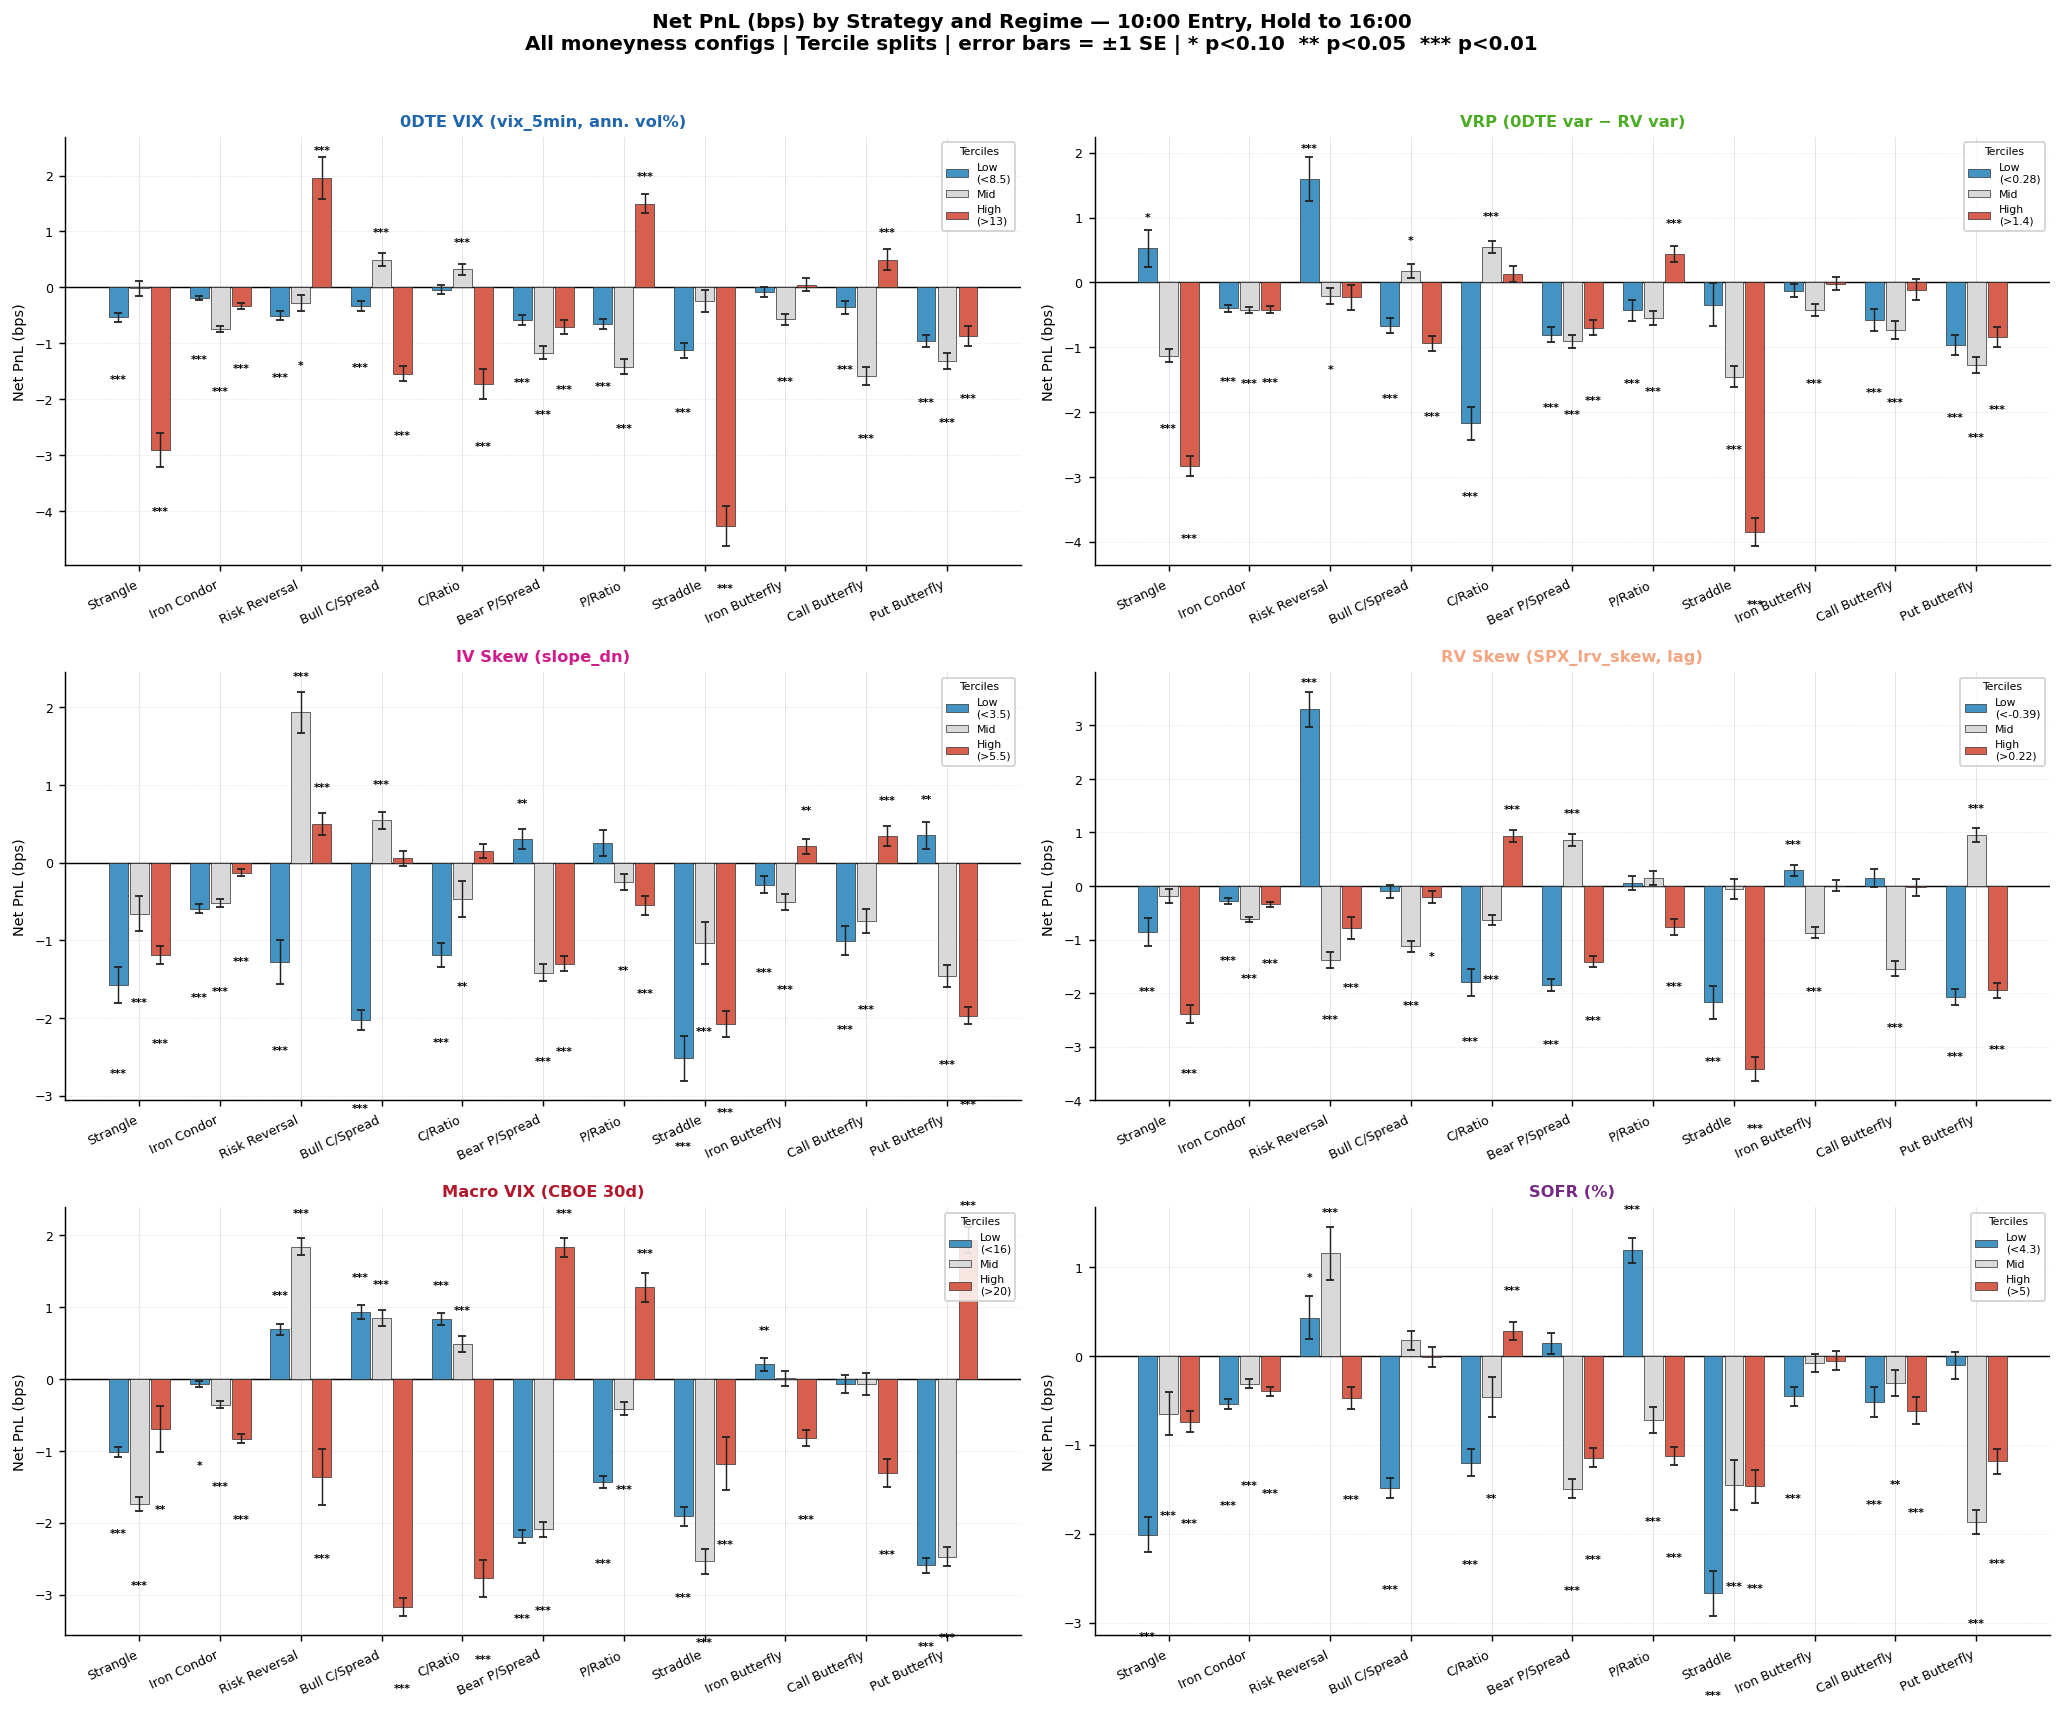

Saved: /Users/dnn/Oxford/0DTE Options/0dte-strategies/output/figures/regime_grid_all_signals.pdf


In [110]:
# ── Multi-signal regime grid ──────────────────────────────────────────────────
# Each panel: mean net PnL (bps) per strategy × tercile of one conditioning signal.
# All signals at 10:00 on the trade date (same-day conditioning, no look-ahead).

import matplotlib.gridspec as gridspec

# -- Merge macro signals into df if not already present ----------------------
macro_raw = pd.read_csv(MACRO)
macro_raw['quote_date'] = pd.to_datetime(macro_raw['quote_date'])
macro_signals = macro_raw[['quote_date', 'vix', 'sofr']].rename(
    columns={'vix': 'vix_macro', 'sofr': 'sofr_macro'}
)

# VIX 0DTE : intégrale de variance SPXW same-day depuis vix_5min (dts=0)
# Converti en vol annualisée % → sqrt(vix_raw * 252) * 100  (même unité que iv_atm)
vix_0dte_raw = pd.read_parquet(DERIVED / 'vix_5min.parquet')
vix_0dte_raw['quote_date'] = pd.to_datetime(vix_0dte_raw['quote_date'])
vix_0dte_raw['quote_time'] = vix_0dte_raw['quote_time'].astype(str).str[:5]
vix_0dte_raw = vix_0dte_raw[(vix_0dte_raw['dts']==0) & (vix_0dte_raw['quote_time']=='10:00')]
if 'root' in vix_0dte_raw.columns:
    vix_0dte_raw = vix_0dte_raw[vix_0dte_raw['root']=='SPXW']
vix_0dte_raw = (vix_0dte_raw.groupby('quote_date', as_index=False)['vix']
                             .mean()
                             .rename(columns={'vix': 'vix_0dte_var'}))
vix_0dte_raw['vix_0dte'] = np.sqrt(vix_0dte_raw['vix_0dte_var'].clip(0) * 252) * 100  # vol ann. %

df2_full = (df
             .merge(macro_signals,                         on='quote_date', how='left')
             .merge(vix_0dte_raw[['quote_date','vix_0dte']], on='quote_date', how='left'))
# Filter to rep mnes for regime bars (pool all entry times, daily signal is the same)
df2 = df2_full[df2_full['mnes'] == df2_full['option_type'].map(REP_MNES)].copy()

# -- Build tercile regime columns for all 6 signals --------------------------
SIGNALS = [
    ('vix_0dte',   '0DTE VIX (vix_5min, ann. vol%)',  '#2166ac'),
    ('vrp',        'VRP (0DTE var − RV var)',           '#4dac26'),
    ('iv_skew',    'IV Skew (slope_dn)',                '#d01c8b'),
    ('rv_skew',    'RV Skew (SPX_lrv_skew, lag)',      '#f4a582'),
    ('vix_macro',  'Macro VIX (CBOE 30d)',              '#b2182b'),
    ('sofr_macro', 'SOFR (%)',                          '#762a83'),
]

for col, _, _ in SIGNALS:
    q33, q67 = df2[col].quantile([1/3, 2/3])
    lo = f'Low\n(<{q33:.2g})'
    hi = f'High\n(>{q67:.2g})'
    md = f'Mid'
    df2[f'{col}_q'] = pd.cut(
        df2[col],
        bins=[-np.inf, q33, q67, np.inf],
        labels=[lo, md, hi]
    )

# -- Generic plotting function -----------------------------------------------
def plot_regime_bars(ax, df_plot, regime_col, color, title):
    regimes = df_plot[regime_col].cat.categories.tolist()
    rc = {regimes[0]: '#4393c3', regimes[1]: '#d9d9d9', regimes[2]: '#d6604d'}

    stats_df = (
        df_plot.groupby(['option_type', regime_col], observed=True)['reth_und_net']
        .agg(['mean', 'std', 'count']).reset_index()
    )
    stats_df['se'] = stats_df['std'] / np.sqrt(stats_df['count'])

    pval_df = (
        df_plot.groupby(['option_type', regime_col], observed=True)['reth_und_net']
        .apply(lambda g: stats.ttest_1samp(g.dropna(), 0).pvalue)
        .reset_index(name='pval')
    )
    stats_df = stats_df.merge(pval_df, on=['option_type', regime_col])

    x = np.arange(len(STRAT_KEYS))
    w = 0.26
    for i, regime in enumerate(regimes):
        sub = (
            stats_df[stats_df[regime_col] == regime]
            .set_index('option_type').reindex(STRAT_KEYS)
        )
        bars = ax.bar(x + (i-1)*w, sub['mean'] * 1e4, width=w*0.9,
                      label=str(regime).replace('\\n', ' '),
                      color=rc[regime], edgecolor='#333', lw=0.4, zorder=3)
        ax.errorbar(x + (i-1)*w, sub['mean'] * 1e4, yerr=sub['se'] * 1e4,
                    fmt='none', color='#222', capsize=2, lw=0.8, zorder=4)
        for bar, row in zip(bars, sub.itertuples()):
            st = sig_stars(row.pval) if hasattr(row, 'pval') and not np.isnan(row.pval) else ''
            h = bar.get_height()
            if st and np.isfinite(h):
                ax.text(bar.get_x() + bar.get_width()/2,
                        h + 0.4 if h >= 0 else h - 1.2,
                        st, ha='center', va='bottom', fontsize=6, fontweight='bold')

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([STRAT_LBL[s] for s in STRAT_KEYS], rotation=25, ha='right', fontsize=7)
    ax.set_ylabel('Net PnL (bps)', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold', color=color)
    ax.legend(fontsize=6, loc='upper right', framealpha=0.85,
              title='Terciles', title_fontsize=6)
    ax.grid(axis='y', lw=0.4, ls=':', alpha=0.5)
    ax.tick_params(labelsize=7)

# -- Draw 3×2 grid -----------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
axes_flat = axes.flatten()

for ax, (col, title, color) in zip(axes_flat, SIGNALS):
    plot_regime_bars(ax, df2, f'{col}_q', color, title)

fig.suptitle(
    'Net PnL (bps) by Strategy and Regime — 10:00 Entry, Hold to 16:00\n'
    'All moneyness configs | Tercile splits | error bars = ±1 SE | * p<0.10  ** p<0.05  *** p<0.01',
    fontsize=11, fontweight='bold', y=1.01
)
fig.tight_layout()
out_path = REPO / 'output' / 'figures' / 'regime_grid_all_signals.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')
